In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import cmocean.cm as cmo
plt.rcParams.update({'font.size': 20})

/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
### Bathy
ncfile_etopo1 = "/media/disk2/vincent/process_profiles/data/external_supports/GEBCO_ker_large.nc"
ds_topo = xr.open_dataset(ncfile_etopo1)
elevation = ds_topo.elevation[::10,::10]
### Fronts
ds_front = xr.open_dataset("/media/disk2/vincent/process_profiles/data/external_supports/62985.nc")
### CMA
ds_CMA = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/CMA_gridded.nc")
### GLORYS
ds_G = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_gridded.nc")
### GLORYS_CL
ds_CL = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_CL_gridded.nc")

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
### Region to mask (Kerguelen)
lon_min, lon_max = 68.25, 70.75
lat_min, lat_max = -50, -48

# Build a 2D mask on the shared lon/lat grid
mask = (
    (ds_G.longitude >= lon_min) & (ds_G.longitude <= lon_max)
    & (ds_G.latitude >= lat_min) & (ds_G.latitude <= lat_max)
)

# Apply mask to each dataset
ds_G_masked = ds_G.where(~mask)
ds_CMA_masked = ds_CMA.where(~mask)
ds_CL_masked = ds_CL.where(~mask)


# We plot a 2D map of the MLD distribution over the region (averaged over time)

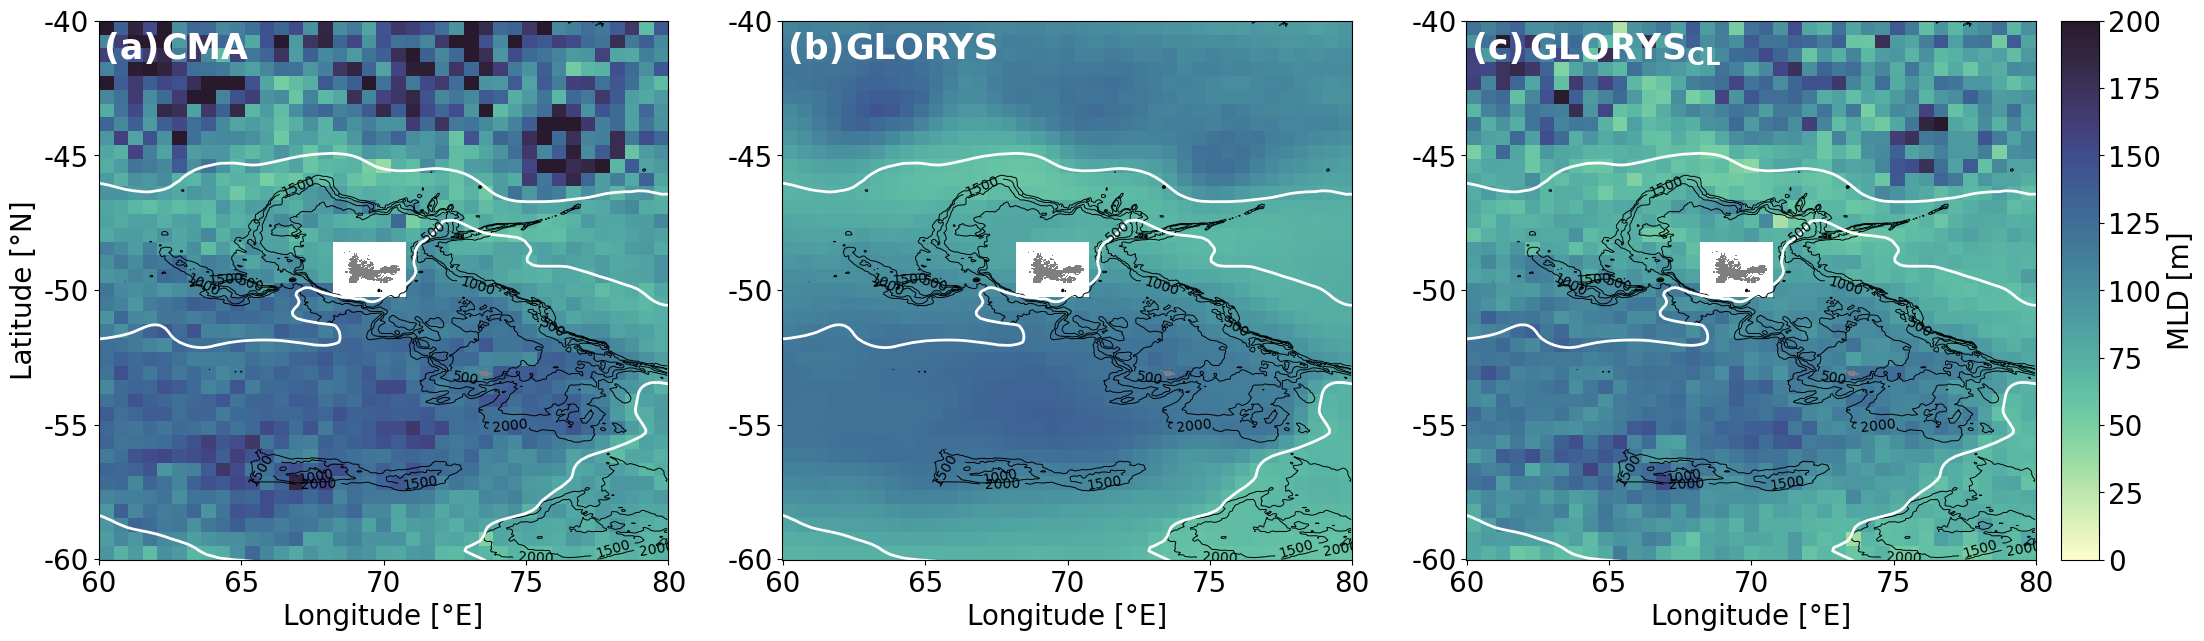

In [5]:
ds1 = ds_CMA_masked.mean("time")
ds2 = ds_G_masked.mean("time")
ds3 = ds_CL_masked.mean("time")
ds_diff = ds3.mld - ds1.mld

cmap = cmo.deep
fig, axs = plt.subplots(1, 3, figsize=(25, 7), gridspec_kw={"wspace": 0.2})

for ax, img in zip(axs, [ds1.mld, ds2.mld, ds3.mld]):
    pcm = img.plot(x="longitude", cmap=cmap, add_colorbar=False, ax=ax, vmin=0, vmax=200)
    (elevation / elevation).where(elevation > 0).plot(add_colorbar=False, cmap="gist_yarg", ax=ax)
    CS = (-elevation).plot.contour(levels=(500, 1000, 1500, 2000), colors="black", linewidths=0.7, ax=ax)

    ax.plot(ds_front.LonSACCF, ds_front.LatSACCF, c="white", linewidth=2)
    ax.plot(ds_front.LonSAF.where(ds_front.LatSAF > -50), ds_front.LatSAF.where(ds_front.LatSAF > -50), c="white", linewidth=2)
    ax.plot(ds_front.LonPF, ds_front.LatPF, c="white", linewidth=2)

    ax.set_yticks([-60, -55, -50, -45, -40])
    ax.set_xticks([60, 65, 70, 75, 80])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.clabel(CS, inline=True, fmt='%1.0f', fontsize=10)
    ax.set_xlabel("Longitude [°E]")
    ax.set_ylabel("")

axs[0].set_ylabel("Latitude [°N]")

pos = axs[2].get_position()
cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.015, pos.height])
fig.colorbar(pcm, cax=cax, label="MLD [m]")

axs[0].text(0.01, 0.93, "(a)", transform=axs[0].transAxes, size=25, color="white", weight="bold")
axs[0].text(0.11, 0.93, "CMA", transform=axs[0].transAxes, size=25, color="white", weight="bold")
axs[1].text(0.01, 0.93, "(b)", transform=axs[1].transAxes, size=25, color="white", weight="bold")
axs[1].text(0.11, 0.93, "GLORYS", transform=axs[1].transAxes, size=25, color="white", weight="bold")
axs[2].text(0.01, 0.93, "(c)", transform=axs[2].transAxes, size=25, color="white", weight="bold")
axs[2].text(0.11, 0.93, r"GLORYS$_{\mathregular{CL}}$", transform=axs[2].transAxes, size=25, color="white", weight="bold")

fig.savefig("/home/jupyter-vincent2/vincent/process_profiles/figures_2026/Figure_2_map_mld.png", bbox_inches="tight", dpi=300)

In [4]:
a = ds1.mld.stack(points=("longitude", "latitude"))
b = ds3.mld.stack(points=("longitude", "latitude"))

valid = a.notnull() & b.notnull()
mld_corr = xr.corr(a.where(valid, drop=True), b.where(valid, drop=True), dim="points")

print(f"MLD Pearson correlation (ds1 vs ds2): {float(mld_corr):.3f}")

MLD Pearson correlation (ds1 vs ds2): 0.727
